In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import test as test
import networkx as nx
from tqdm import tqdm
import plotly.express as px

In [2]:
epidist_data = pd.read_csv('./Data/epidist.csv')
bepidist_data = pd.read_csv('./Data/bepidist.csv')
epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'V', 'T']
bepidist_data =  bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'V', 'T']
epidist_data = epidist_data.apply(pd.to_numeric)
bepidist_data = bepidist_data.apply(pd.to_numeric)

### Example of disease peaks differences depeding on utility shape parameter

0.0021999999999999797
0.013000000000000012
0.27979999999999994
0.41059999999999997


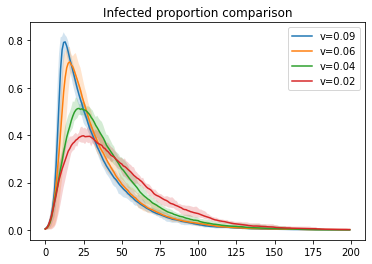

In [3]:
vs = [0.09, 0.06, 0.04, 0.02]
T = 7
n = 500

plt.figure()

for v in vs:

    epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
    bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

    mean = (epidist['i_mean']/n).tolist()
    lower = (epidist['i_min']/n).tolist()
    upper = (epidist['i_max']/n).tolist()

    meanb = (bepidist['i_mean']/n).tolist()
    lowerb = (bepidist['i_min']/n).tolist()
    upperb = (bepidist['i_max']/n).tolist()

    diff = np.nanmax(mean) - np.nanmax(meanb)
    print(diff)

    # plt.plot(mean,'-b', label="Mean classic model")
    # # fill the area with black color, opacity 0.15
    # plt.fill_between(list(range(len(mean))), upper, lower, color="b", alpha=0.2)

    plt.plot(meanb, label=f"v={v}")
    # fill the area with black color, opacity 0.15
    plt.fill_between(range(len(meanb)), upperb, lowerb, alpha=0.2)

plt.title("Infected proportion comparison")
plt.legend(loc="upper right")

plt.show()

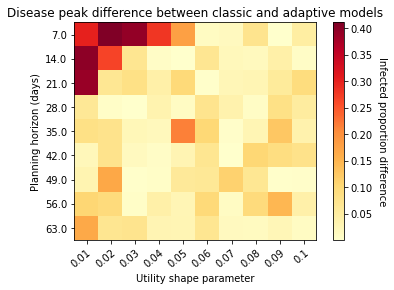

In [4]:
data_diff = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        
        epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean = (epidist['i_mean']/n).tolist()
        meanb = (bepidist['i_mean']/n).tolist()
        
        diff = np.nanmax(mean) - np.nanmax(meanb)
        
        data_diff = pd.concat([data_diff, pd.DataFrame({
            'V': [v],
            'T': [T],
            'diff': [np.abs(diff)]
        })], ignore_index=True)
plot1_data = data_diff.pivot(index='V', columns='T', values='diff')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

# for dat in data:
#     vals = [str(round(val, 4)) for val in list(dat)]
#     vals = f"{{{','.join(vals)}}},"
#     print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = "YlOrRd")

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Infected proportion difference", rotation = -90, va = "bottom")
plt.title(f"Disease peak difference between classic and adaptive models")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Main figure: global vs local efforts

0.5711762324748587


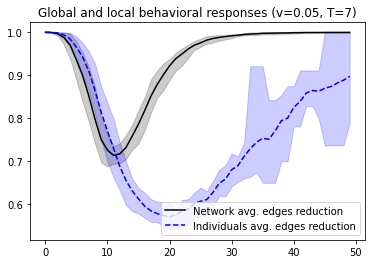

In [5]:
v = 0.05
T = 7
n = 500
epidist = epidist_data[(epidist_data['V'] == v) & (epidist_data['T'] == T)]
bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]

mean_all = bepidist['edgecount_mean'].tolist()
lower_all = bepidist['edgecount_min'].tolist()
upper_all = bepidist['edgecount_max'].tolist()

mean_sus = bepidist['suscedgecount_mean'].tolist()
lower_sus = bepidist['suscedgecount_min'].tolist()
upper_sus = bepidist['suscedgecount_max'].tolist()

print(np.nanmin(bepidist['suscedgecount_mean'].tolist()))

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(range(50), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.title(f"Global and local behavioral responses (v={v}, T={T})")
plt.legend(loc="lower right")
plt.show()

### Min Avg. Edge Reduction (Global/Local)

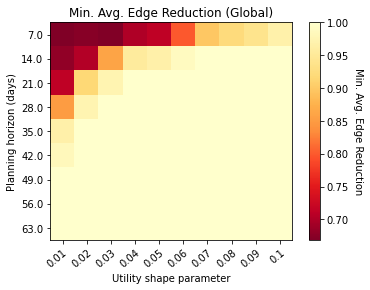

In [8]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['edgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

# for dat in data:
#     vals = [str(round(val, 4)) for val in list(dat)]
#     vals = f"{{{','.join(vals)}}},"
#     print(vals)

##### Reverse colormap
import matplotlib as mpl

def reverse_colourmap(cmap, name = 'my_cmap_r'):
    """
    In: 
    cmap, name 
    Out:
    my_cmap_r

    Explanation:
    t[0] goes from 0 to 1
    row i:   x  y0  y1 -> t[0] t[1] t[2]
                   /
                  /
    row i+1: x  y0  y1 -> t[n] t[1] t[2]

    so the inverse should do the same:
    row i+1: x  y1  y0 -> 1-t[0] t[2] t[1]
                   /
                  /
    row i:   x  y1  y0 -> 1-t[n] t[2] t[1]
    """        
    reverse = []
    k = []   

    for key in cmap._segmentdata:    
        k.append(key)
        channel = cmap._segmentdata[key]
        data = []

        for t in channel:                    
            data.append((1-t[0],t[2],t[1]))            
        reverse.append(sorted(data))    

    LinearL = dict(zip(k,reverse))
    my_cmap_r = mpl.colors.LinearSegmentedColormap(name, LinearL) 
    return my_cmap_r
cmap = mpl.cm.YlOrRd
cmap_r = reverse_colourmap(cmap)    

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

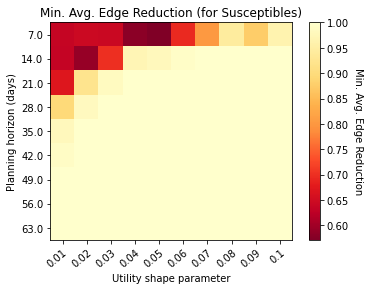

In [10]:
data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_sus = bepidist['suscedgecount_mean'].tolist()
        min_ctc_sus = np.nanmin(mean_sus)
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [min_ctc_sus]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

# for dat in data:
#     vals = [str(round(val, 4)) for val in list(dat)]
#     vals = f"{{{','.join(vals)}}},"
#     print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Min. Avg. Edge Reduction", rotation = -90, va = "bottom")
plt.title(f"Min. Avg. Edge Reduction (for Susceptibles)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Day lag between min edge reductions (Global/Local)

{11,9,10,9,9,12,15,0,20,12},
{12,11,12,1,0,0,0,0,0,0},
{11,17,1,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{1,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},
{0,0,0,0,0,0,0,0,0,0},


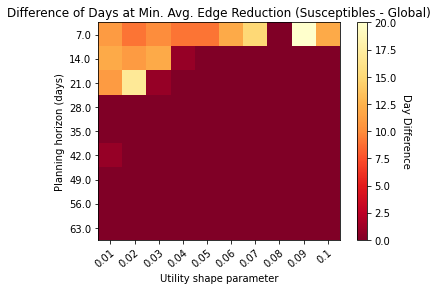

In [11]:
# ------- #

data_min = pd.DataFrame({})
for v in epidist_data['V'].unique():
    for T in epidist_data['T'].unique():
        bepidist = bepidist_data[(bepidist_data['V'] == v) & (bepidist_data['T'] == T)]
        
        mean_ctc_ = bepidist['edgecount_mean'].tolist()
        min_ctc_day_ = np.nanargmin(mean_ctc_)
        
        mean_ctc_sus_ = bepidist['suscedgecount_mean'].tolist()
        min_ctc_day_sus_ = np.nanargmin(mean_ctc_sus_)
        
        day_lag_ = min_ctc_day_sus_ - min_ctc_day_
        
        data_min = pd.concat([data_min, pd.DataFrame({
            'V': [v],
            'T': [T],
            'min': [day_lag_]
        })], ignore_index=True)
        
plot1_data = data_min.pivot(index='V', columns='T', values='min')
# Labels
xlabs = list(plot1_data.index)
ylabs = plot1_data.columns.tolist()
data = np.transpose(np.abs(plot1_data.values))

for dat in data:
    vals = [str(round(val, 4)) for val in list(dat)]
    vals = f"{{{','.join(vals)}}},"
    print(vals)

# Heat map
fig, ax = plt.subplots()
im = ax.imshow(data, cmap = cmap_r)

# Add the labels
# We want to show all ticks...
ax.set_xticks(np.arange(len(xlabs)))
ax.set_yticks(np.arange(len(ylabs)))
# ... and label them with the respective list entries
ax.set_xticklabels(xlabs)
ax.set_yticklabels(ylabs)

# Rotate the labels of the X-axis
plt.setp(ax.get_xticklabels(), rotation = 40,
         ha = "right", rotation_mode = "anchor")

# Add the color bar
cbar = ax.figure.colorbar(im, ax = ax)
cbar.ax.set_ylabel("Day Difference", rotation = -90, va = "bottom")
plt.title(f"Difference of Days at Min. Avg. Edge Reduction (Susceptibles - Global)")
plt.xlabel("Utility shape parameter")
plt.ylabel("Planning horizon (days)")
plt.show()

### Population distributions example

In [12]:
dist_example = pd.read_csv('./distribution_example.csv')

dist_example = dist_example.reset_index()
dist_example.columns = ['node', 'v', 'T']

print('Sub population 1: More risk averse. More susceptible to diminish contacts.')
print(dist_example.head(200)['v'].mean())
print(dist_example.head(200)['T'].mean())

print('Sub population 2: Less risk averse. Less susceptible to diminish contacts.')
print(dist_example.tail(300)['v'].mean())
print(dist_example.tail(300)['T'].mean())

Sub population 1: More risk averse. More susceptible to diminish contacts.
0.05
7.0
Sub population 2: Less risk averse. Less susceptible to diminish contacts.
0.08
16.0


In [13]:
# y = dist_example['T']
# print(list(y[0:200]))
# print(list(y[200:]))
# plt.hist(y)
# plt.show()

In [14]:
# z = dist_example['v']
# print(list(z[0:200]))
# print(list(z[200:]))
# plt.hist(z)
# plt.show()

In [15]:
bepidist_data = pd.read_csv('./Data/Distribution_bepidist.csv')
bepidist_data

,day,s_mean,s_min,s_max,s_std,i_mean,i_min,i_max,i_std,r_mean,...,r_max,r_std,edgecount_mean,edgecount_min,edgecount_max,edgecount_std,suscedgecount_mean,suscedgecount_min,suscedgecount_max,suscedgecount_std
0,1,497.28,499,493,1.370833,2.66,7,1,1.379293,0.06,...,0,0.239898,0.999793,1.000000,0.998727,0.000300,0.999982,1.000000,0.999549,0.000072
1,2,493.64,499,482,3.480324,6.00,14,1,3.103652,0.36,...,0,0.749422,0.998612,1.000000,0.994589,0.001481,0.999396,1.000000,0.997737,0.000649
2,3,487.08,497,467,7.207819,12.20,29,2,6.727950,0.72,...,0,0.904411,0.995114,1.000000,0.982015,0.004754,0.997606,1.000000,0.991048,0.002368
3,4,474.36,497,446,13.329054,24.10,53,3,12.758750,1.54,...,0,1.232386,0.986109,1.000000,0.955276,0.010897,0.992766,1.000000,0.975696,0.005882
4,5,451.16,492,399,24.027501,45.56,97,8,22.842102,3.28,...,0,2.099951,0.966580,0.999045,0.912303,0.021085,0.981180,0.999546,0.946149,0.012922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,0.04,1,0,0.197949,0.20,1,0,0.404061,499.76,...,499,0.431419,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
196,197,0.04,1,0,0.197949,0.20,1,0,0.404061,499.76,...,499,0.431419,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
197,198,0.04,1,0,0.197949,0.18,1,0,0.388088,499.78,...,499,0.418452,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
198,199,0.04,1,0,0.197949,0.16,1,0,0.370328,499.80,...,499,0.404061,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000


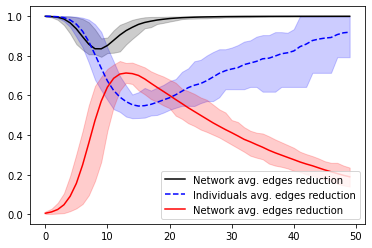

In [16]:
bepidist = bepidist_data.copy()

i_mean = bepidist['i_mean'].astype(float).tolist()
i_mean = [i/500 for i in i_mean]

i_min = bepidist['i_min'].astype(float).tolist()
i_min = [i/500 for i in i_min]

i_max = bepidist['i_max'].astype(float).tolist()
i_max = [i/500 for i in i_max]

mean_all = bepidist['edgecount_mean'].astype(float).tolist()
lower_all = bepidist['edgecount_min'].astype(float).tolist()
upper_all = bepidist['edgecount_max'].astype(float).tolist()

mean_sus = bepidist['suscedgecount_mean'].astype(float).tolist()
lower_sus = bepidist['suscedgecount_min'].astype(float).tolist()
upper_sus = bepidist['suscedgecount_max'].astype(float).tolist()

plt.figure()
plt.plot(mean_all[0:50],'-k', label="Network avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color="k", alpha=0.2)
plt.plot(mean_sus[0:50], linestyle='--', color='b', label="Individuals avg. edges reduction")
plt.fill_between(range(50), upper_sus[0:50], lower_sus[0:50], color="b", alpha=0.2)
plt.plot(i_mean[0:50],'-r', label="Network avg. edges reduction")
plt.fill_between(range(50), i_max[0:50], i_min[0:50], color="r", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

In [28]:
# print(f"""{{
# {','.join([str(round(a,4)) for a in mean_all[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in upper_all[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in lower_all[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in mean_sus[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in upper_sus[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in lower_sus[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in i_mean[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in i_max[0:50]])}
# }},
# \n
# {{
# {','.join([str(round(a,4)) for a in i_min[0:50]])}
# }}
# \n
# """)

#### Examining contact behavior in subpopulations

In [17]:
bepcontacts = pd.read_csv('./Data/Distribution_bepidist_contacts.csv')
print(bepcontacts.shape)
bepcontacts

(25000, 202)


,index,node,day_0,day_1,day_2,day_3,day_4,day_5,day_6,day_7,...,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199
0,0,0,23,23,23,23,23,22,22,21,...,23,23,23,23,23,23,23,23,23,23
1,0,1,26,26,26,26,26,26,24,24,...,26,26,26,26,26,26,26,26,26,26
2,0,2,27,27,27,27,27,27,27,26,...,27,27,27,27,27,27,27,27,27,27
3,0,3,20,20,20,20,20,18,18,18,...,20,20,20,20,20,20,20,20,20,20
4,0,4,27,27,27,27,27,26,23,23,...,27,27,27,27,27,27,27,27,27,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,49,495,25,25,25,25,25,25,25,25,...,25,25,25,25,25,25,25,25,25,25
24996,49,496,32,32,32,32,32,32,32,22,...,32,32,32,32,32,32,32,32,32,32
24997,49,497,23,23,23,23,13,16,17,20,...,23,23,23,23,23,23,23,23,23,23
24998,49,498,17,17,17,17,17,17,13,16,...,17,17,17,17,17,17,17,17,17,17


In [18]:
bepcontacts_long = pd.melt(bepcontacts, id_vars=['index', 'node'],
                           value_vars=[col for col in bepcontacts.columns if col.startswith('day')])
bepcontacts_long

,index,node,variable,value
0,0,0,day_0,23
1,0,1,day_0,26
2,0,2,day_0,27
3,0,3,day_0,20
4,0,4,day_0,27
...,...,...,...,...
4999995,49,495,day_199,25
4999996,49,496,day_199,32
4999997,49,497,day_199,23
4999998,49,498,day_199,17


In [19]:
bepcontacts_long_max = bepcontacts_long.groupby(['index', 'node'])['value'].max().reset_index()
bepcontacts_long_max.columns = ['index', 'node', 'value_max']
bepcontacts_long_max

,index,node,value_max
0,0,0,23
1,0,1,26
2,0,2,27
3,0,3,20
4,0,4,27
...,...,...,...
24995,49,495,25
24996,49,496,32
24997,49,497,23
24998,49,498,17


In [20]:
bepcontacts_long_norm = bepcontacts_long.merge(bepcontacts_long_max, left_on=['index', 'node'], right_on=['index', 'node'])
bepcontacts_long_norm['norm_value'] = bepcontacts_long_norm['value']/bepcontacts_long_norm['value_max']
bepcontacts_long_norm['pop'] = np.where(bepcontacts_long_norm['node']<200, 1, 2)
bepcontacts_long_norm = bepcontacts_long_norm.rename(columns={'variable':'day'})
bepcontacts_long_norm['day'] = bepcontacts_long_norm['day'].apply(lambda x: int(x.replace('day_','')))
bepcontacts_long_norm

,index,node,day,value,value_max,norm_value,pop
0,0,0,0,23,23,1.0,1
1,0,0,1,23,23,1.0,1
2,0,0,2,23,23,1.0,1
3,0,0,3,23,23,1.0,1
4,0,0,4,23,23,1.0,1
...,...,...,...,...,...,...,...
4999995,49,499,195,30,30,1.0,2
4999996,49,499,196,30,30,1.0,2
4999997,49,499,197,30,30,1.0,2
4999998,49,499,198,30,30,1.0,2


In [11]:
# bepcontacts_long_norm[(bepcontacts_long_norm['node']==0) & (bepcontacts_long_norm['day']==11)]
# bepcontacts_long_norm[(bepcontacts_long_norm['node']==0) & (bepcontacts_long_norm['index']==44)].head(60)

In [21]:
df = bepcontacts_long_norm.groupby(['pop', 'day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})

df.columns = df.columns.droplevel()
df.columns = ['pop', 'day', 'mean', 'max', 'min', 'std']

df['lower'] = df['mean'] - df['std']
df['upper'] = df['mean'] + df['std']
df['upper'] = df['upper'].apply(lambda x: min(x,1))

df = df.sort_values(by=['day'])
print(df['max'].unique())

df

[1.]


,pop,day,mean,max,min,std,lower,upper
0,1,0,0.999677,1.0,0.760000,0.004233,0.995444,1.0
200,2,0,0.999888,1.0,0.840000,0.002673,0.997215,1.0
1,1,1,0.997768,1.0,0.720000,0.011503,0.986265,1.0
201,2,1,0.999263,1.0,0.705882,0.008812,0.990451,1.0
2,1,2,0.991821,1.0,0.652174,0.024408,0.967413,1.0
...,...,...,...,...,...,...,...,...
197,1,197,1.000000,1.0,1.000000,0.000000,1.000000,1.0
398,2,198,1.000000,1.0,1.000000,0.000000,1.000000,1.0
198,1,198,1.000000,1.0,1.000000,0.000000,1.000000,1.0
199,1,199,1.000000,1.0,1.000000,0.000000,1.000000,1.0


In [22]:
df0 = bepcontacts_long_norm.groupby(['node', 'day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})
df0.columns = df0.columns.droplevel()
df0.columns = ['node', 'day', 'mean', 'max', 'min', 'std']
df0 = df0.sort_values(by=['node', 'day'])
df0 = df0[df0['day']<50]
df1 = df0[df0['node']<200]
df2 = df0[df0['node']>=200]
df0

,node,day,mean,max,min,std
0,0,0,1.000000,1.0,1.000000,0.000000
1,0,1,0.998261,1.0,0.956522,0.008606
2,0,2,0.988696,1.0,0.652174,0.050314
3,0,3,0.968696,1.0,0.652174,0.065167
4,0,4,0.939130,1.0,0.608696,0.088277
...,...,...,...,...,...,...
99845,499,45,0.999333,1.0,0.966667,0.004714
99846,499,46,0.999333,1.0,0.966667,0.004714
99847,499,47,0.999333,1.0,0.966667,0.004714
99848,499,48,0.999333,1.0,0.966667,0.004714


In [23]:
# fig = px.line(df1, x="day", y="mean", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

# fig = px.line(df1, x="day", y="min", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

In [24]:
# fig = px.line(df2, x="day", y="mean", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

# fig = px.line(df2, x="day", y="min", color='node', color_discrete_sequence=px.colors.qualitative.Set2)
# fig.show()

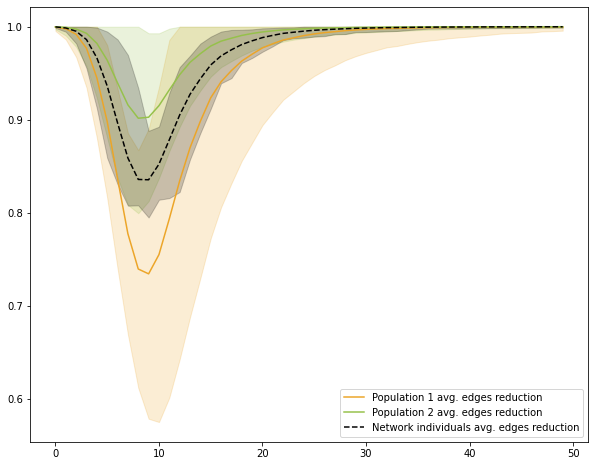

In [25]:
plt.figure(figsize=(10,8))

plt.plot(range(50), df[df['pop']==1]['mean'][0:50],'#ECA528', label="Population 1 avg. edges reduction")
plt.fill_between(range(50),
                df[df['pop']==1]['lower'][0:50],
                df[df['pop']==1]['upper'][0:50],
                color='#ECA528', alpha=0.2)

plt.plot(range(50), df[df['pop']==2]['mean'][0:50],'#96C14B', label="Population 2 avg. edges reduction")
plt.fill_between(range(50),
                df[df['pop']==2]['lower'][0:50],
                df[df['pop']==2]['upper'][0:50],
                color='#96C14B', alpha=0.2)

plt.plot(mean_all[0:50], linestyle='--', color='k', label="Network individuals avg. edges reduction")
plt.fill_between(range(50), upper_all[0:50], lower_all[0:50], color='k', alpha=0.2)

plt.legend(loc="lower right")
plt.show()

### Bifurcation plot examination
Not important ...

In [71]:
# epidist_data = pd.read_csv('./Data/epidist_bifurcation.csv')
# bepidist_data = pd.read_csv('./Data/bepidist_bifurcation.csv')
# epidist_data =  epidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
# epidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
# 'r_mean', 'r_min', 'r_max', 'pi', 'pr']
# epidist_data = epidist_data.apply(pd.to_numeric)
# epidist_data
# bepidist_data = bepidist_data.drop(columns=['Unnamed: 0']).iloc[1: , :]
# bepidist_data.columns = ['day', 's_mean', 's_min', 's_max', 'i_mean', 'i_min', 'i_max', 
#                          'r_mean', 'r_min', 'r_max', 'edgecount_mean', 'edgecount_min', 'edgecount_max',
# 'suscedgecount_mean', 'suscedgecount_min', 'suscedgecount_max', 'pi', 'pr']
# bepidist_data = bepidist_data.apply(pd.to_numeric)
# bepidist_data
# dat = pd.DataFrame(epidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
# plt.scatter(dat['pi'], dat['i_mean'])
# plt.show()
# dat = pd.DataFrame(bepidist_data.groupby(['pi'])['i_mean'].mean()).reset_index()
# plt.scatter(dat['pi'], dat['i_mean'])
# plt.show()
# dat1 = epidist_data[epidist_data['pi']==0.0069]
# dat2 = bepidist_data[bepidist_data['pi']==0.0069]
# print(dat1['i_mean'].max())
# print(dat2['i_mean'].max())
# print(dat1['i_mean'].mean())
# print(dat2['i_mean'].mean())
# plt.plot(range(dat1.shape[0]), dat1['i_mean'], range(dat1.shape[0]), dat2['i_mean'])
# plt.show()
# diffs = []
# mean_diffs = []
# for pi in epidist_data['pi'].unique().tolist():
#     dat1 = epidist_data[epidist_data['pi']==pi]
#     dat2 = bepidist_data[bepidist_data['pi']==pi]
#     diff = dat1['i_mean'].max() - dat2['i_mean'].max()
#     diffs.append(diff)
#     mean_diff = dat1['i_mean'].mean() - dat2['i_mean'].mean()
#     mean_diffs.append(mean_diff)
# plt.plot(epidist_data['pi'].unique().tolist(), mean_diffs)
# plt.show()
# plt.plot(epidist_data['pi'].unique().tolist(), diffs)
# plt.show()

## Sensitivity to network connectivity
***Review experiments and polish them for appendix***

Experiment with Erdos-Renyi

In [26]:
bepidist_data_c = pd.read_csv('./Data/bepidist_ntwk_conn_erdos_renyi_1000.csv')
bepidist_data_c = bepidist_data_c.groupby(['ped'], as_index=False).agg({'day_lags': ['mean', 'max', 'min', 'std']})
bepidist_data_c.columns = bepidist_data_c.columns.droplevel()
bepidist_data_c.columns = ['ped', 'mean', 'max', 'min', 'std']
bepidist_data_c['lower'] = bepidist_data_c['mean'] - bepidist_data_c['std']
bepidist_data_c['lower'] = bepidist_data_c['lower'].apply(lambda x: max(x, 0))
bepidist_data_c['upper'] = bepidist_data_c['mean'] + bepidist_data_c['std']
bepidist_data_c = bepidist_data_c[bepidist_data_c['ped']>=0.01]
bepidist_data_c

,ped,mean,max,min,std,lower,upper
9,0.010,9.24,20,0,4.340413,4.899587,13.580413
10,0.011,9.24,14,0,3.414017,5.825983,12.654017
11,0.012,9.36,18,0,2.876790,6.483210,12.236790
12,0.013,8.90,14,0,2.573412,6.326588,11.473412
13,0.014,8.54,12,0,2.260666,6.279334,10.800666
...,...,...,...,...,...,...,...
95,0.096,0.04,1,0,0.197949,0.000000,0.237949
96,0.097,0.04,1,0,0.197949,0.000000,0.237949
97,0.098,0.10,1,0,0.303046,0.000000,0.403046
98,0.099,0.10,1,0,0.303046,0.000000,0.403046


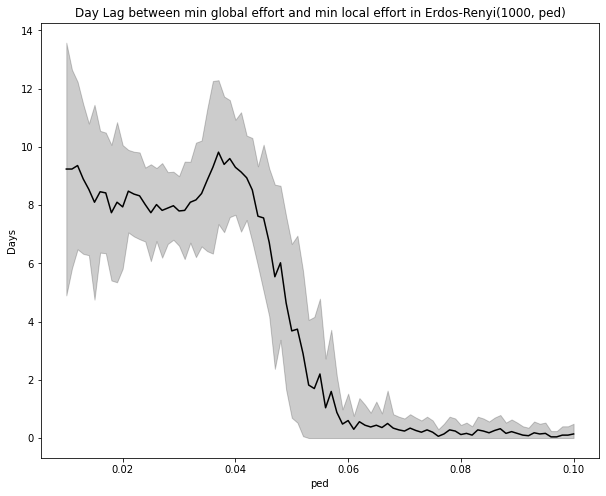

In [27]:
plt.figure(figsize=(10,8))
plt.plot(bepidist_data_c['ped'], bepidist_data_c['mean'], '-k', label="Network avg. edges reduction")
plt.fill_between(bepidist_data_c['ped'], bepidist_data_c['lower'], bepidist_data_c['upper'], color="k", alpha=0.2)
plt.title("Day Lag between min global effort and min local effort in Erdos-Renyi(1000, ped)")
plt.xlabel("ped")
plt.ylabel("Days")
plt.show()

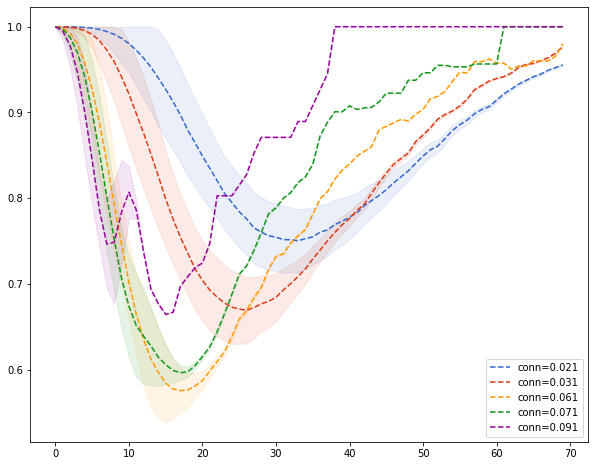

In [28]:
def transform_data(n, ped):

    dat_ = pd.read_csv(f'./Data/bepidist_contacts_ntwk_conn_erdos_renyi_{n}_{ped}.csv')
    dat_['i'] = dat_['i']/n
    dat_ = dat_.groupby(['day'], as_index=False).agg({'i': ['mean', 'max', 'min', 'std'], 
                                                    'edgecount': ['mean', 'max', 'min', 'std'],
                                                    'suscedgecount': ['mean', 'max', 'min', 'std']
                                                   })
    dat_.columns = dat_.columns.droplevel()
    dat_.columns = ['day', 'i_mean', 'i_max', 'i_min', 'i_std',
                    'edgecount_mean', 'edgecount_max', 'edgecount_min', 'edgecount_std',
                    'suscedgecount_mean', 'suscedgecount_max', 'suscedgecount_min', 'suscedgecount_std']
    
    dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
    dat_['i_lower'] = dat_['i_lower'].apply(lambda x: max(x,0))
    
    dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
    dat_['i_upper'] = dat_['i_upper'].apply(lambda x: min(x,1))
    
    dat_['edgecount_lower'] = dat_['edgecount_mean'] - dat_['edgecount_std']
    dat_['edgecount_lower'] = dat_['edgecount_lower'].apply(lambda x: max(x,0))
    dat_['edgecount_upper'] = dat_['edgecount_mean'] + dat_['edgecount_std']
    dat_['edgecount_upper'] = dat_['edgecount_upper'].apply(lambda x: min(x,1))
    
    dat_['suscedgecount_lower'] = dat_['suscedgecount_mean'] - dat_['edgecount_std']
    dat_['suscedgecount_lower'] = dat_['suscedgecount_lower'].apply(lambda x: max(x,0))
    dat_['suscedgecount_upper'] = dat_['suscedgecount_mean'] + dat_['edgecount_std']
    dat_['suscedgecount_upper'] = dat_['suscedgecount_upper'].apply(lambda x: min(x,1))
    
    return dat_

conns = [round(conn, 4) for conn in np.linspace(0.001, 0.1, 100)]
sample_conns = [conns[i] for i in range(0,len(conns),10)]

sample_conns = [0.021, 0.031, 0.061, 0.071, 0.091]

plt.figure(figsize=(10,8))

mins_reds_days = []
mins_reds = []

for idx, sampconn in enumerate(sample_conns):
    
    maxd = 70
    dat_ = transform_data(500, sampconn)
    
    # plt.plot(dat_['edgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"conn={sampconn}")
    # plt.fill_between(range(maxd), dat_['edgecount_lower'][0:maxd], dat_['edgecount_upper'][0:maxd],
    #                  color=px.colors.qualitative.G10[idx], alpha=0.2)
    
    plt.plot(dat_['suscedgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"conn={sampconn}", linestyle='dashed')
    plt.fill_between(range(maxd), dat_['suscedgecount_lower'][0:maxd], dat_['suscedgecount_upper'][0:maxd],
                     color=px.colors.qualitative.G10[idx], alpha=0.1)

    # minn = min(dat_['edgecount_mean'][0:maxd])
    # mins_reds.append(minn)
    # mins_reds_days.append(list(dat_['edgecount_mean'][0:maxd]).index(minn))
    
# plt.plot(mins_reds_days, mins_reds, color='k', linestyle='dashed')
    
plt.legend(loc="lower right")
plt.show()

In [29]:
# print(f"""
# xr1000 = {{ { ','.join([str(x) for x in bepidist_data_c['ped']])}  }}; \n
# mean1000 = {{ { ','.join([str(x) for x in bepidist_data_c['mean']])}  }}; \n
# lower1000 = {{ { ','.join([str(round(x,4)) for x in bepidist_data_c['lower']])}  }}; \n
# upper1000 = {{ { ','.join([str(round(x,4)) for x in bepidist_data_c['upper']])}  }};
# """)

# for idx, sampconn in enumerate(sample_conns):
    
#     maxd = 70
#     dat_ = transform_data(500, sampconn)
    
#     print(f"""
#     meanconn{idx} = {{ { ','.join([str(round(x,4)) for x in dat_['suscedgecount_mean'][0:maxd]])}  }}; \n
#     lowerconn{idx} = {{ { ','.join([str(round(x,4)) for x in dat_['suscedgecount_lower'][0:maxd]])}  }}; \n
#     upperconn{idx} = {{ { ','.join([str(round(x,4)) for x in dat_['suscedgecount_upper'][0:maxd]])}  }};
#     """)

### Barabasi Albert Network

In [30]:
bepidist_data_ba = pd.read_csv('./Data/bepidist_ntwk_barabasi_albert_1000.csv')
bepidist_data_ba = bepidist_data_ba.groupby(['m'], as_index=False).agg({'day_lags': ['mean', 'max', 'min', 'std']})
bepidist_data_ba.columns = bepidist_data_ba.columns.droplevel()
bepidist_data_ba.columns = ['m', 'mean', 'max', 'min', 'std']
bepidist_data_ba['lower'] = bepidist_data_ba['mean'] - bepidist_data_ba['std']
bepidist_data_ba['lower'] = bepidist_data_ba['lower'].apply(lambda x: max(x, 0))
bepidist_data_ba['upper'] = bepidist_data_ba['mean'] + bepidist_data_ba['std']
bepidist_data_ba.head(10)

,m,mean,max,min,std,lower,upper
0,5,7.56,13,0,3.393631,4.166369,10.953631
1,6,6.36,12,0,3.305901,3.054099,9.665901
2,7,7.52,13,0,2.719844,4.800156,10.239844
3,8,6.72,12,0,2.642201,4.077799,9.362201
4,9,7.52,13,0,2.168795,5.351205,9.688795
5,10,7.06,10,0,1.856154,5.203846,8.916154
6,11,6.42,10,0,2.348165,4.071835,8.768165
7,12,6.30,10,5,1.129385,5.170615,7.429385
8,13,5.86,9,0,2.030482,3.829518,7.890482
9,14,6.30,11,0,2.052873,4.247127,8.352873


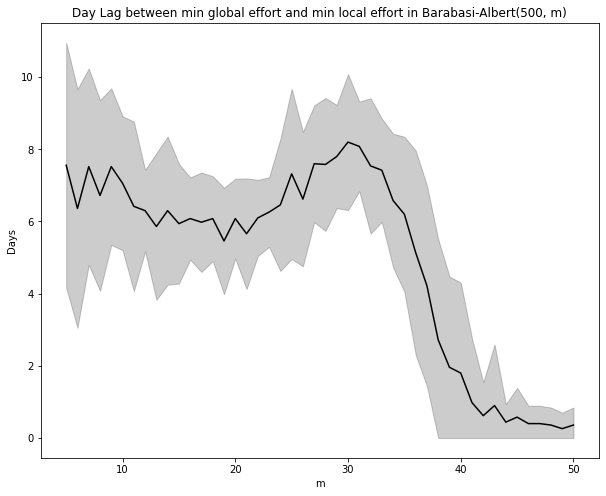

In [31]:
plt.figure(figsize=(10,8))
days = 50
plt.plot(bepidist_data_ba['m'], bepidist_data_ba['mean'],'-k', label="Network avg. edges reduction")
plt.fill_between(bepidist_data_ba['m'], bepidist_data_ba['lower'], bepidist_data_ba['upper'], color="k", alpha=0.2)
plt.title("Day Lag between min global effort and min local effort in Barabasi-Albert(500, m)")
plt.xlabel("m")
plt.ylabel("Days")
plt.show()

In [32]:
# print(f"""
# xsb1 = {{ { ','.join([str(x) for x in bepidist_data_ba['m']])}  }}; \n
# meanb1 = {{ { ','.join([str(x) for x in bepidist_data_ba['mean']])}  }}; \n
# lowerb1 = {{ { ','.join([str(round(x,4)) for x in bepidist_data_ba['lower']])}  }}; \n
# upperb1 = {{ { ','.join([str(round(x,4)) for x in bepidist_data_ba['upper']])}  }};
# """)

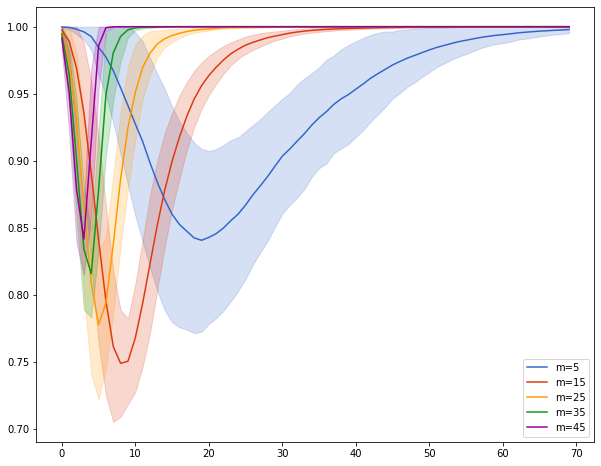

In [33]:
def transform_data(n, m):

    dat_ = pd.read_csv(f'./Data/bepidist_contacts_ntwk_barabasi_albert_{n}_{m}.csv')
    dat_['i'] = dat_['i']/n
    dat_ = dat_.groupby(['day'], as_index=False).agg({'i': ['mean', 'max', 'min', 'std'], 
                                                    'edgecount': ['mean', 'max', 'min', 'std'],
                                                    'suscedgecount': ['mean', 'max', 'min', 'std']
                                                   })
    dat_.columns = dat_.columns.droplevel()
    dat_.columns = ['day', 'i_mean', 'i_max', 'i_min', 'i_std',
                    'edgecount_mean', 'edgecount_max', 'edgecount_min', 'edgecount_std',
                    'suscedgecount_mean', 'suscedgecount_max', 'suscedgecount_min', 'suscedgecount_std']
    
    dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
    dat_['i_lower'] = dat_['i_lower'].apply(lambda x: max(x,0))
    
    dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
    dat_['i_upper'] = dat_['i_upper'].apply(lambda x: min(x,1))
    
    dat_['edgecount_lower'] = dat_['edgecount_mean'] - dat_['edgecount_std']
    dat_['edgecount_lower'] = dat_['edgecount_lower'].apply(lambda x: max(x,0))
    dat_['edgecount_upper'] = dat_['edgecount_mean'] + dat_['edgecount_std']
    dat_['edgecount_upper'] = dat_['edgecount_upper'].apply(lambda x: min(x,1))
    
    dat_['suscedgecount_lower'] = dat_['suscedgecount_mean'] - dat_['edgecount_std']
    dat_['suscedgecount_lower'] = dat_['suscedgecount_lower'].apply(lambda x: max(x,0))
    dat_['suscedgecount_upper'] = dat_['suscedgecount_mean'] + dat_['edgecount_std']
    dat_['suscedgecount_upper'] = dat_['suscedgecount_upper'].apply(lambda x: min(x,1))
    
    return dat_

mms = [5,15,25,35,45]

plt.figure(figsize=(10,8))

mins_reds_days = []
mins_reds = []

for idx, m in enumerate(mms):
    
    maxd = 70
    dat_ = transform_data(500, m)
    
    plt.plot(dat_['edgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"m={m}")
    plt.fill_between(range(maxd), dat_['edgecount_lower'][0:maxd], dat_['edgecount_upper'][0:maxd],
                     color=px.colors.qualitative.G10[idx], alpha=0.2)
    
    # plt.plot(dat_['suscedgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"m={m}", linestyle='dashed')
    # plt.fill_between(range(maxd), dat_['suscedgecount_lower'][0:maxd], dat_['suscedgecount_upper'][0:maxd],
    #                  color=px.colors.qualitative.G10[idx], alpha=0.1)

    # minn = min(dat_['edgecount_mean'][0:maxd])
    # mins_reds.append(minn)
    # mins_reds_days.append(list(dat_['edgecount_mean'][0:maxd]).index(minn))
    
# plt.plot(mins_reds_days, mins_reds, color='k', linestyle='dashed')
    
plt.legend(loc="lower right")
plt.show()

In [34]:
# for idx, m in enumerate(mms):
    
#     maxd = 70
#     dat_ = transform_data(500, m)
    
#     print(f"""
#     meanconn{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['suscedgecount_mean'][0:maxd]])}  }}; \n
#     lowerconn{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['suscedgecount_lower'][0:maxd]])}  }}; \n
#     upperconn{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['suscedgecount_upper'][0:maxd]])}  }};
#     """)

### Small world network

- n : int
The number of nodes

- k : int
Each node is connected to k nearest neighbors in ring topology

- p : float
The probability of rewiring each edge

In [35]:
bepidist_data_sw = pd.read_csv('./Data/bepidist_ntwk_small_world_1000.csv')
bepidist_data_sw = bepidist_data_sw.groupby(['m', 'ped'], as_index=False).agg({'day_lags': ['mean', 'max', 'min', 'std']})
bepidist_data_sw.columns = bepidist_data_sw.columns.droplevel()
bepidist_data_sw.columns = ['m', 'ped', 'mean', 'max', 'min', 'std']
bepidist_data_sw['lower'] = bepidist_data_sw['mean'] - bepidist_data_sw['std']
bepidist_data_sw['lower'] = bepidist_data_sw['lower'].apply(lambda x: max(x, 0))
bepidist_data_sw['upper'] = bepidist_data_sw['mean'] + bepidist_data_sw['std']
bepidist_data_sw

,m,ped,mean,max,min,std,lower,upper
0,5,0.001,7.74,117,0,20.459826,0.000000,28.199826
1,5,0.012,5.94,69,0,13.492870,0.000000,19.432870
2,5,0.023,9.78,107,0,23.331935,0.000000,33.111935
3,5,0.034,11.50,134,-4,30.241376,0.000000,41.741376
4,5,0.045,6.82,126,-11,20.248144,0.000000,27.068144
...,...,...,...,...,...,...,...,...
95,50,0.056,1.84,6,0,1.113186,0.726814,2.953186
96,50,0.067,1.86,9,0,1.414358,0.445642,3.274358
97,50,0.078,1.74,7,0,1.290626,0.449374,3.030626
98,50,0.089,1.36,10,0,1.453497,0.000000,2.813497


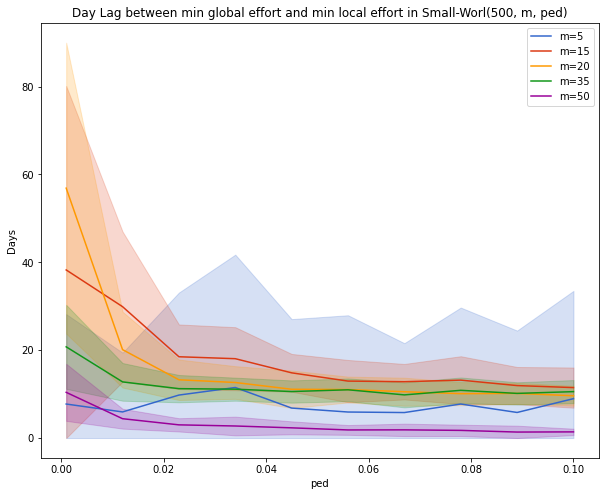

In [36]:
plt.figure(figsize=(10,8))
mms = bepidist_data_sw['m'].unique()
mms = [5, 15, 20, 35, 50]
for idx, m in enumerate(mms):
    dat = bepidist_data_sw[bepidist_data_sw['m'] == m]
    plt.plot(dat['ped'], dat['mean'], color=px.colors.qualitative.G10[idx],
             label=f"m={m}")
    plt.fill_between(dat['ped'], dat['lower'], dat['upper'], color=px.colors.qualitative.G10[idx], alpha=0.2)
plt.title("Day Lag between min global effort and min local effort in Small-Worl(500, m, ped)")
plt.xlabel("ped")
plt.ylabel("Days")
plt.legend(loc="upper right")
plt.show()

In [37]:
# print(f"""xssw = {{ { ','.join([str(x) for x in dat['ped']])}  }}; \n""")

# for idx, m in enumerate(mms):
#     dat = bepidist_data_sw[bepidist_data_sw['m'] == m]
#     print(f"""mean{idx} = {{ { ','.join([str(x) for x in dat['mean']])}  }};
# lower{idx} = {{ { ','.join([str(round(x,4)) for x in dat['lower']])}  }};
# upper{idx} = {{ { ','.join([str(round(x,4)) for x in dat['upper']])}  }}; \n """)
    
# print(','.join([f'mean{i},lower{i},upper{i}' for i in range(5)]))
# print(','.join(['{xssw}']*15))

# for idx, m in enumerate(mms):
#     print(f'Directive[Thick, ToColor[RGBColor["{px.colors.qualitative.G10[idx]}"], Hue]], None, None,')
    
# for k in range(5):
#     print(f'{{{3*k+1} -> {{{3*k+2}}} }}, {{{3*k+1} -> {{{3*(k+1)}}} }},')

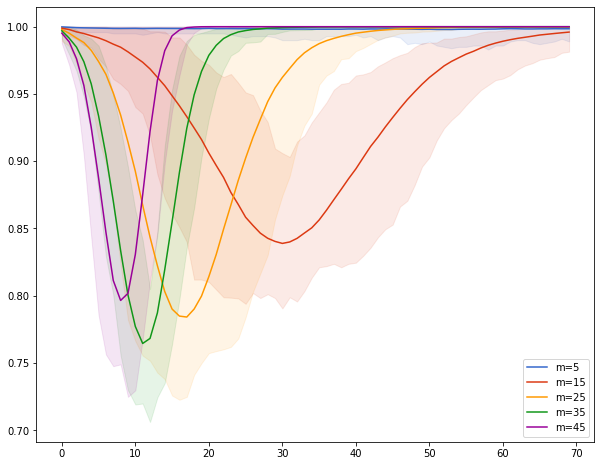

In [38]:
def transform_data(n, m, ped):

    dat_ = pd.read_csv(f'./Data/bepidist_contacts_ntwk_small_world_{n}_{m}_{ped}.csv')
    dat_['i'] = dat_['i']/n
    dat_ = dat_.groupby(['day'], as_index=False, dropna=False).agg({'i': ['mean', 'max', 'min', 'std'], 
                                                    'edgecount': ['mean', 'max', 'min', 'std'],
                                                    'suscedgecount': ['mean', 'max', 'min', 'std']
                                                   })
    dat_.columns = dat_.columns.droplevel()
    dat_.columns = ['day', 'i_mean', 'i_max', 'i_min', 'i_std',
                    'edgecount_mean', 'edgecount_max', 'edgecount_min', 'edgecount_std',
                    'suscedgecount_mean', 'suscedgecount_max', 'suscedgecount_min', 'suscedgecount_std']
    
    dat_['i_lower'] = dat_['i_mean'] - dat_['i_std']
    dat_['i_lower'] = dat_['i_lower'].apply(lambda x: max(x,0))
    
    dat_['i_upper'] = dat_['i_mean'] + dat_['i_std']
    dat_['i_upper'] = dat_['i_upper'].apply(lambda x: min(x,1))
    
    dat_['edgecount_lower'] = dat_['edgecount_mean'] - dat_['edgecount_std']
    dat_['edgecount_lower'] = dat_['edgecount_lower'].apply(lambda x: max(x,0))
    dat_['edgecount_upper'] = dat_['edgecount_mean'] + dat_['edgecount_std']
    dat_['edgecount_upper'] = dat_['edgecount_upper'].apply(lambda x: min(x,1))
    
    dat_['suscedgecount_lower'] = dat_['suscedgecount_mean'] - dat_['edgecount_std']
    dat_['suscedgecount_lower'] = dat_['suscedgecount_lower'].apply(lambda x: max(x,0))
    dat_['suscedgecount_upper'] = dat_['suscedgecount_mean'] + dat_['edgecount_std']
    dat_['suscedgecount_upper'] = dat_['suscedgecount_upper'].apply(lambda x: min(x,1))
    
    return dat_

mms = [5,15,25,35,45]

plt.figure(figsize=(10,8))

mins_reds_days = []
mins_reds = []

for idx, m in enumerate(mms):
    
    maxd = 70
    dat_ = transform_data(500, m, 0.078)

    plt.plot(dat_['edgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"m={m}")
    plt.fill_between(range(maxd), dat_['edgecount_min'][0:maxd], dat_['edgecount_max'][0:maxd],
                     color=px.colors.qualitative.G10[idx], alpha=0.1)
    
    # plt.plot(dat_['suscedgecount_mean'][0:maxd],color=px.colors.qualitative.G10[idx], label=f"m={m}", linestyle='dashed')
    # plt.fill_between(range(maxd), dat_['suscedgecount_min'][0:maxd], dat_['suscedgecount_max'][0:maxd],
    #                  color=px.colors.qualitative.G10[idx], alpha=0.1)

    # minn = min(dat_['edgecount_mean'][0:maxd])
    # mins_reds.append(minn)
    # mins_reds_days.append(list(dat_['edgecount_mean'][0:maxd]).index(minn))
    
# plt.plot(mins_reds_days, mins_reds, color='k', linestyle='dashed')

plt.legend(loc="lower right")
plt.show()

In [39]:
# for idx, m in enumerate(mms):
#     maxd = 100
#     dat_ = transform_data(500, m, 0.023)
#     print(f"""
#     meanconn{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['edgecount_mean'][0:maxd]])}  }}; \n
#     lowerconn{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['edgecount_lower'][0:maxd]])}  }}; \n
#     upperconn{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['edgecount_upper'][0:maxd]])}  }};
    
#     meanconn{idx}S = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['suscedgecount_mean'][0:maxd]])}  }}; \n
#     lowerconn{idx}S = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['suscedgecount_lower'][0:maxd]])}  }}; \n
#     upperconn{idx}S = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['suscedgecount_upper'][0:maxd]])}  }};
    
    
#     """)
    
# for idx, m in enumerate(mms):
#     maxd = 200
#     dat_ = transform_data(500, m, 0.023)
#     print(f"""
#     imean{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['i_mean'][0:maxd]])}  }}; \n
#     ilower{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['i_lower'][0:maxd]])}  }}; \n
#     iupper{idx} = {{ { ','.join([str(round(x,4)).replace('nan','NaN') for x in dat_['i_upper'][0:maxd]])}  }};
#     """)

## Articles of interest:
- https://www.pnas.org/doi/10.1073/pnas.2123355119
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.88.042802
- https://journals.aps.org/pre/pdf/10.1103/PhysRevE.77.066101
- https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.96.208701
- https://www.sciencedirect.com/science/article/pii/S0022039618304182
- https://ieeexplore.ieee.org/abstract/document/8502826

# Comparison with adaptive SIR model

In [40]:
from SIR_adaptive import RunAdaptiveSim, SIRB

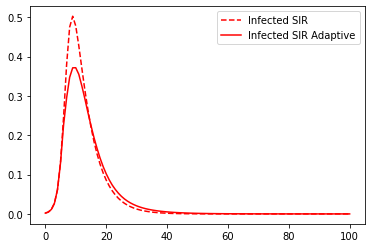

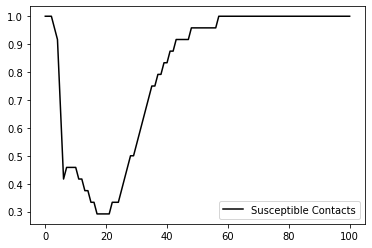

In [41]:
# Initial conditions
s0 = 499
i0 = 1
r0 = 0
n = s0 + i0 + r0

# Population parameters
Lambda = 0 # Mortality rate is mu = Lambda/N
Mu = Lambda/n

# Disease parameters
Beta = 0.045
Gamma = 0.2

# Optimization parameters
T = 14
Nu = 0.1
Delta = 0.99986
maxcr = 24
cred = 1
iutred = 0

# Final time 
tft = 100 
# Timestep lengths 
DeltaT = 1

# Infected and recovered contacts rates (fixed) *)
ci = int(maxcr)
cr = int(maxcr)

s, i, r, ctime = RunAdaptiveSim(s0, i0, r0,
               Lambda, Beta, Gamma, 
               T, Nu, Delta,
               maxcr, cred, iutred,
               tft, DeltaT)

s1, i1, r1 = SIRB([s0, i0, r0],
                  [Lambda, Mu], [Beta, Gamma], 
                  [ctime[0], ci, cr], 
                  [0, tft+1], steps=None)

ctime = [c/maxcr for c in ctime]
i = [ii/n for ii in i]
i1 = [ii1/n for ii1 in i1]

# plt.figure()
# plt.plot(s1,'#5E81B5', linestyle='dashed', label="Susceptibles SIR")
# plt.plot(s,'#5E81B5', label="Susceptibles SIR Adaptive")
# plt.legend(loc="upper right")

plt.figure()
plt.plot(i1,'red', linestyle='dashed', label="Infected SIR")
plt.plot(i,'red', label="Infected SIR Adaptive")
plt.legend(loc="upper right")

# plt.figure()
# plt.plot(r1,'-k', linestyle='dashed', label="Recovered SIR")
# plt.plot(r,'-k', label="Recovered SIR Adaptive")
# plt.legend(loc="upper right")

plt.figure()
plt.plot(ctime,'-k', label="Susceptible Contacts")
plt.legend(loc="lower right")

In [42]:
bepidist = pd.read_csv('./Data/ExampleNetworkNodes_bepidist.csv')
i_net = [i/500 for i in bepidist['i_mean']]

In [43]:
# import itertools
# from sklearn.metrics import mean_squared_error
# Betas = np.linspace(0.001, 0.5, 10)
# Gammas = np.linspace(0.001, 0.5, 10)
# Ts = range(7,17)
# Nus = np.linspace(0.0001, 0.2, 10)
# combs = list(itertools.product(Betas, Gammas, Ts, Nus))
# errors = []
# for comb in tqdm(combs):
#     s, i, r, ctime = RunAdaptiveSim(s0, i0, r0,
#                Lambda, comb[0], comb[1], 
#                comb[2], comb[3], Delta,
#                maxcr, cred, iutred,
#                tft, DeltaT)
#     i = [ii/n for ii in i]
#     errors.append(mean_squared_error(i_net, i))

In [44]:
### Compare to network adaptive.
bepcontacts = pd.read_csv('./Data/ExampleNetworkNodes_contacts.csv')
bepcontacts = bepcontacts[bepcontacts['index']==0]

print(bepcontacts.shape)

bepcontacts_long = pd.melt(bepcontacts, id_vars=['index', 'node'],
                           value_vars=[col for col in bepcontacts.columns if col.startswith('day')])
bepcontacts_long_max = bepcontacts_long.groupby(['index', 'node'])['value'].max().reset_index()
bepcontacts_long_max.columns = ['index', 'node', 'value_max']
bepcontacts_long_norm = bepcontacts_long.merge(bepcontacts_long_max, left_on=['index', 'node'], right_on=['index', 'node'])
bepcontacts_long_norm['norm_value'] = bepcontacts_long_norm['value']/bepcontacts_long_norm['value_max']
bepcontacts_long_norm = bepcontacts_long_norm.rename(columns={'variable':'day'})
bepcontacts_long_norm['day'] = bepcontacts_long_norm['day'].apply(lambda x: int(x.replace('day_','')))

bepcontacts_long_norm

(500, 802)


,index,node,day,value,value_max,norm_value
0,0,0,0,26,26,1.0
1,0,0,1,26,26,1.0
2,0,0,2,26,26,1.0
3,0,0,3,26,26,1.0
4,0,0,4,26,26,1.0
...,...,...,...,...,...,...
99995,0,499,195,27,27,1.0
99996,0,499,196,27,27,1.0
99997,0,499,197,27,27,1.0
99998,0,499,198,27,27,1.0


In [45]:
# dfn = bepcontacts[bepcontacts['node'] == list(np.random.randint(low=0, high=499, size=(1,)))[0]]
# df1 = pd.melt(dfn, id_vars=['node'],
#         value_vars=[col for col in bepcontacts.columns if col.startswith('day')])[['variable', 'value']]
# df1.columns = ['day', 'ctcs']
# df1['day'] = df1['day'].apply(lambda x: int(x.replace('day_', '')))
# df2 = pd.melt(dfn, id_vars=['node'],
#         value_vars=[col for col in bepcontacts.columns if col.startswith('i_')])[['variable', 'value']]
# df2.columns = ['day', 'infected']
# df2['day'] = df2['day'].apply(lambda x: int(x.replace('i_day_', '')))
# dff = df1.merge(df2, left_on=['day'], right_on=['day'])

# plt.figure(figsize=(10,8))
# plt.plot(dff['ctcs'],px.colors.qualitative.G10[idx], linestyle='dashed', label='Contacts')
# plt.plot(dff['infected'],'-k', label="Infected status", linewidth=3)
# plt.legend(loc="lower right")

In [46]:
df2 = pd.melt(bepcontacts, id_vars=['node'],
        value_vars=[col for col in bepcontacts.columns if col.startswith('s_')])
df2.columns = ['node', 'day', 'susceptible']
df2['day'] = df2['day'].apply(lambda x: int(x.replace('s_day_', '')))
df_susc_ctcs = bepcontacts_long_norm.merge(df2, left_on=['node','day'], right_on=['node','day'])
df_susc_ctcs = df_susc_ctcs[df_susc_ctcs['susceptible']==1]
df_susc_ctcs = df_susc_ctcs.groupby(['day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})
df_susc_ctcs.columns = df_susc_ctcs.columns.droplevel()
df_susc_ctcs.columns = ['day', 'mean', 'max', 'min', 'std']
df_susc_ctcs

,day,mean,max,min,std
0,0,1.000000,1.000000,1.000000,0.000000
1,1,1.000000,1.000000,1.000000,0.000000
2,2,0.999904,1.000000,0.952381,0.002138
3,3,0.998774,1.000000,0.904762,0.007466
4,4,0.996958,1.000000,0.900000,0.012533
...,...,...,...,...,...
59,59,0.857143,0.857143,0.857143,NaN
60,60,0.857143,0.857143,0.857143,NaN
61,61,0.857143,0.857143,0.857143,NaN
62,62,0.857143,0.857143,0.857143,NaN


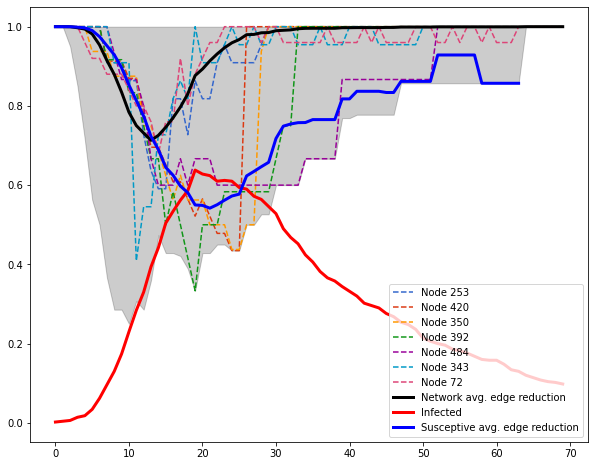

In [47]:
df = bepcontacts_long_norm.copy()
df = df[df['day']<70]
# sample_nodes = list(np.random.randint(low=0, high=499, size=(6,)))
# print(sample_nodes)
# # sample_nodes = [155, 403, 149, 251, 66, 420], [252, 316, 253, 284, 389, 350] [58, 494, 420, 112, 392, 107]
# # [484, 459, 26, 129, 227, 366], [271, 377, 246, 9, 401, 343], [206, 216, 72, 344, 57, 433]
# # 420, 350, 392, 484, 343, 72
sample_nodes = [253, 420, 350, 392, 484, 343, 72]

df = df[df['node'].isin(sample_nodes)]

df_agg = bepcontacts_long_norm.copy()
df_agg = df_agg[df_agg['day']<70]
df_agg = df_agg.groupby(['day'], as_index=False).agg({'norm_value': ['mean', 'max', 'min', 'std']})
df_agg.columns = df_agg.columns.droplevel()
df_agg.columns = ['day', 'mean', 'max', 'min', 'std']
df_agg['lower'] = df_agg['mean'] - df_agg['std']
df_agg['upper'] = df_agg['mean'] + df_agg['std']
df_agg['upper'] = df_agg['upper'].apply(lambda x: min(x, 1))

plt.figure(figsize=(10,8))
for idx, node in enumerate(sample_nodes):
    plt.plot(range(70), df[df['node'] == node]['norm_value'],px.colors.qualitative.G10[idx], linestyle='dashed', label=f'Node {node}')
plt.plot(range(70), df_agg['mean'],'-k', label="Network avg. edge reduction", linewidth=3)
plt.fill_between(range(70), df_agg['min'], df_agg['max'], color="k", alpha=0.2)
plt.plot(range(70), i_net[0:70],'red', label="Infected", linewidth=3)
plt.plot(df_susc_ctcs['mean'],'blue', label="Susceptive avg. edge reduction", linewidth=3)
plt.legend(loc="lower right")

Different adaptation process for each node.

#### Simple layers example: see in notebook `adaptive_layer_experiment.ipynb`

### Max edge reduction depending on network connectivity

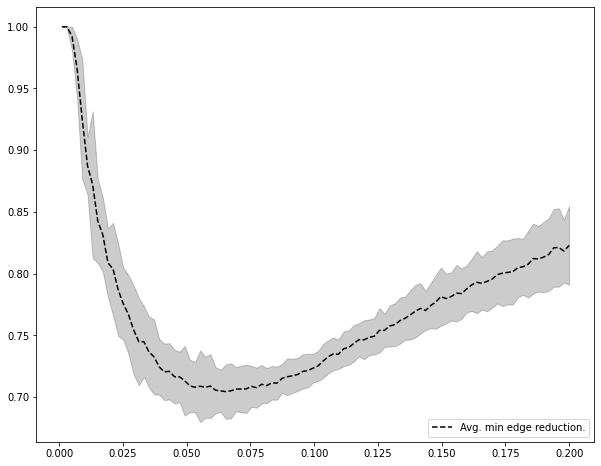

In [5]:
df_ = pd.read_csv('./Data/bepidist_erdos_renyi_500_min_mean_effort.csv')
df_['lower_effort'] = df_['mean_effort'] - 3*df_['std_effort']
df_['upper_effort'] = df_['mean_effort'] + 3*df_['std_effort']
df_['lower_effort'] = df_['lower_effort'].apply(lambda x: max(x, 0))
df_['upper_effort'] = df_['upper_effort'].apply(lambda x: min(x, 1))
plt.figure(figsize=(10,8))
plt.plot(df_['ped'], df_['mean_effort'], color = 'k',
         linestyle='dashed', label='Avg. min edge reduction.')
plt.fill_between(df_['ped'], df_['lower_effort'], df_['upper_effort'], color="k", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

In [65]:
# print(f"""
# peds = {{ {','.join([str(round(x,5)) for x in df_['ped']])} }};
# mean_efforts = {{ {','.join([str(round(x,4)) for x in df_['mean_effort']])} }};
# lower_efforts = {{ {','.join([str(round(x,4)) for x in df_['lower_effort']])} }};
# upper_efforts = {{ {','.join([str(round(x,4)) for x in df_['upper_effort']])} }};
# """)

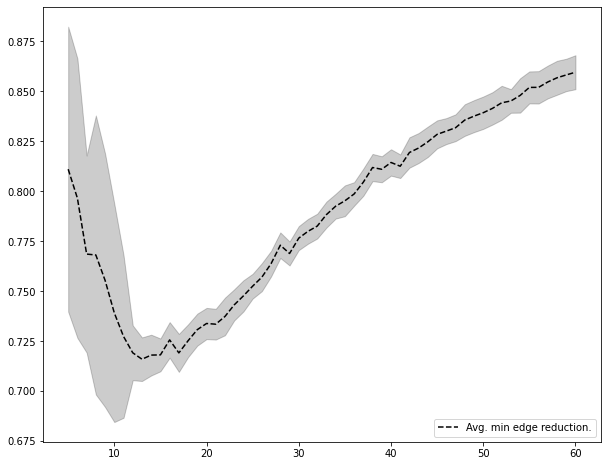

In [73]:
df_ = pd.read_csv('./Data/bepidist_barabasi_albert_500_min_mean_effort.csv')
df_['lower_effort'] = df_['mean_effort'] - std_list # df_['std_effort']
df_['upper_effort'] = df_['mean_effort'] + std_list # df_['std_effort']
df_['lower_effort'] = df_['lower_effort'].apply(lambda x: max(x, 0))
df_['upper_effort'] = df_['upper_effort'].apply(lambda x: min(x, 1))
plt.figure(figsize=(10,8))
plt.plot(df_['m'], df_['mean_effort'], color = 'k',
         linestyle='dashed', label='Avg. min edge reduction.')
plt.fill_between(df_['m'], df_['lower_effort'], df_['upper_effort'], color="k", alpha=0.2)
plt.legend(loc="lower right")
plt.show()

In [74]:
# print(f"""
# mms = {{ {','.join([str(round(x,4)) for x in df_['m']])} }};
# mean_efforts = {{ {','.join([str(round(x,4)) for x in df_['mean_effort']])} }};
# lower_efforts = {{ {','.join([str(round(x,4)) for x in df_['lower_effort']])} }};
# upper_efforts = {{ {','.join([str(round(x,4)) for x in df_['upper_effort']])} }};
# """)